Hypothesis: We don't have to fit all copulas then calculate BIC score to choose the best one. We can calculate the one that fits best with either normal, tail, or asymmetric dependence. 

Importing Iris data set and getting one sepal length feature column instances for the Iris-setosa target.

In [33]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
iris = fetch_ucirepo(id=53)

df = pd.DataFrame(iris.data.features, columns=iris.data.feature_names)
df['target'] = iris.data.targets

sepal_len0 = df.loc[df['target'] == 'Iris-setosa', 'sepal length']
sepal_len1 = df.loc[df['target'] == "Iris-setosa", 'sepal width']
sepal_len2 = df.loc[df['target'] == "Iris-setosa", 'petal length']

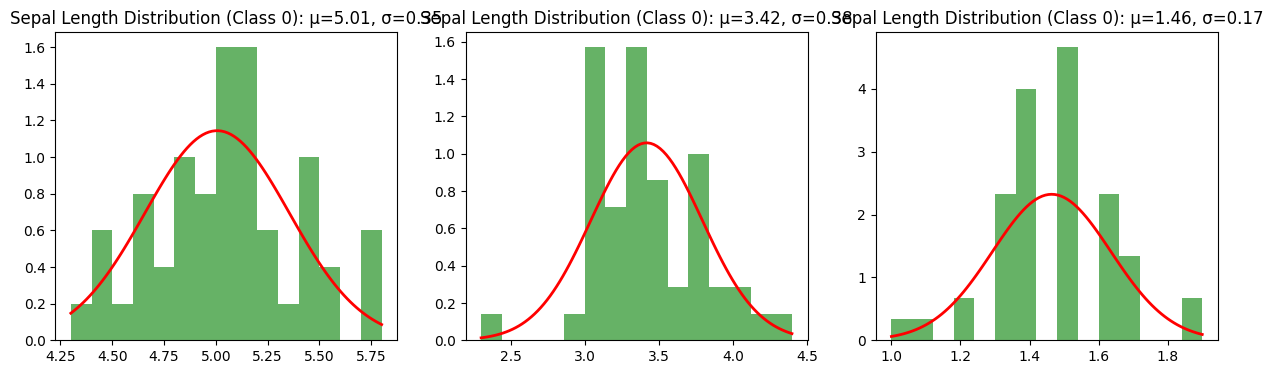

In [34]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Fit a normal distribution
mu0, sigma0 = norm.fit(sepal_len0)
mu1, sigma1 = norm.fit(sepal_len1)
mu2, sigma2 = norm.fit(sepal_len2)

fig, axes = plt.subplots(1, 3, figsize=(15,4))


# Plot histogram
axes[0].hist(sepal_len0, bins=15, density=True, alpha=0.6, color='g')
axes[1].hist(sepal_len1, bins=15, density=True, alpha=0.6, color='g')
axes[2].hist(sepal_len2, bins=15, density=True, alpha=0.6, color='g')

# Plot the PDF
x = np.linspace(min(sepal_len0), max(sepal_len0), 100)
y = np.linspace(min(sepal_len1), max(sepal_len1), 100)
z = np.linspace(min(sepal_len2), max(sepal_len2), 100)

axes[0].plot(x, norm.pdf(x, mu0, sigma0), 'r', linewidth=2)
axes[1].plot(y, norm.pdf(y, mu1, sigma1), 'r', linewidth=2)
axes[2].plot(z, norm.pdf(z, mu2, sigma2), 'r', linewidth=2)

axes[0].set_title(f"Sepal Length Distribution (Class 0): μ={mu0:.2f}, σ={sigma0:.2f}")
axes[1].set_title(f"Sepal Length Distribution (Class 0): μ={mu1:.2f}, σ={sigma1:.2f}")
axes[2].set_title(f"Sepal Length Distribution (Class 0): μ={mu2:.2f}, σ={sigma2:.2f}")
plt.show()

# Visualizing how BIC works